# Week 2 - Polynomial Curve Fitting and Decision Theory

Learning contents:

1. Linear models
    - Linear function
    - Error function
    - Root meant square error
    - Optimization of Error function
    - Test the model
2. Regularization
    - Error function
    - Optimization
    - Test with regularization
3. Model Selection
    - Cross-validation
4. Bayesian curve fitting
    - Display results

## Description

In this exercise we will apply Linear Models for Polynomial Curve Fitting task.

You have to fill empty functions (with pass in body) to match their purpose.

1. You have to create a code for evaluation of a Linear Model, it's error functions and finding optimal weights with given error functions.
2. You need to add regularization to the optimization procedure.
3. You need to implement Cross-validation model selection technique.
4. You need to implement Bayesian curve fitting, computing phi and S matricies at first, then using them to compute mean and variance.

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import  exp
import math

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

In [2]:
def target_func(x): return np.sin(2*np.pi*x)

def generate_data(size):
    rng = np.random.RandomState(26052605)
    x_train = rng.uniform(0., 1., size)
    y_train = target_func(x_train) + rng.normal(scale=0.1, size=size)
    x_test = np.linspace(0., 1., 100)
    y_test = target_func(x_test)
    
    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = generate_data(10)

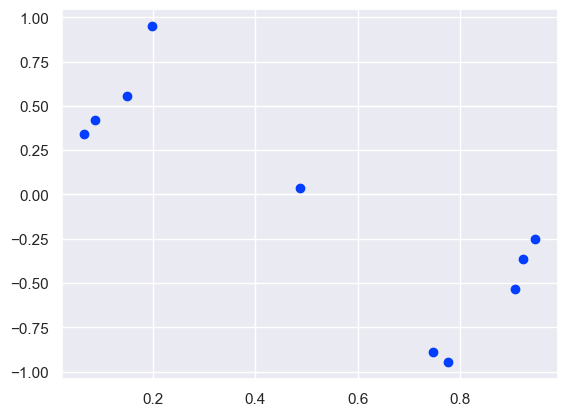

In [3]:
plt.scatter(x_train, y_train)

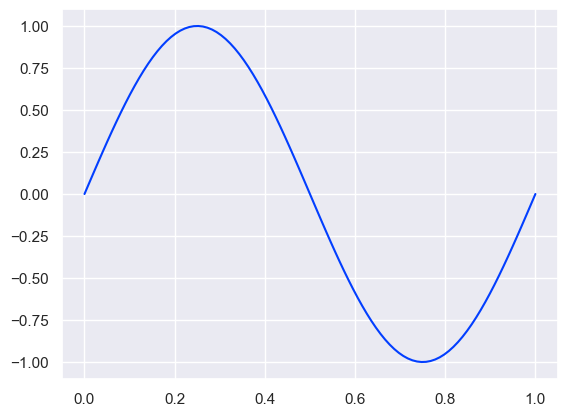

In [4]:
plt.plot(x_test, y_test, '-')

## 1) Linear models

### 1.1) Linear function

Complete the function below, named `linear`, which takes two parameters: a single data point `x` and a list of `M` number of `weights`. The function should return an output value `y` as given in the equation on slide 6 of Lecture 3. In essence, this function should implement a polynomial of order `M`.   

In [5]:
def linear(x, weights):
    sum = 0
    for i in range(len(weights)):
        sum_in_loop = weights[i] * (x**i)
        sum += sum_in_loop
    return sum

linear(1, [1,5])


6

### 1.2) Error function

Complete the function below, named `err`, that computes the sum-of-squared error between the output of the function above and the corresponding target value. Specifically, the function should implement the error equation in slide 7 of Lecture 3. The function takes `weights`, `inputs` and `targets` as parameters

In [6]:
def err(weights, inputs, targets):
    err_sum = 0
    for i in range(len(inputs)):
        err = (linear(inputs[i], weights)-targets[i])**2
        err_sum += err
    return (err_sum/2)

err([1,2,3],[1,2],[3,3])
    

    

102.5

### 1.3) Root meant square error

Write a function for computing the root mean squared error as given in the equation in slide 12 of Lecture 3

In [7]:
def erms(weights, inputs, targets):
    for i in range(len(inputs)):
        pit_stop_rmse = math.sqrt(2*err(weights, inputs, targets)/len(targets))
        return pit_stop_rmse
    
erms([1,2,3],[1,2],[3,3])

10.124228365658293

### 1.4) Optimization of Error function

Create a function below that obtains `optimial_weights` by implementing the optimization solution given in slide 9 of Lecture 3. The function takes the following parameters: `inputs`, `targets`, and `M` (number of weights) as parameters and returns optimal weights for the given set of training data.

In [8]:
def optimial_weights(inputs, targets, M):
    t_t = np.array(targets).T
    t = np.array(targets)
    x_t = np.vander(inputs, M+1, increasing= True).T
    X = np.vander(inputs, M+1, increasing= True)
    total = np.linalg.inv(x_t@X)@x_t@t
    return total



optimial_weights([1,2,3,4],[1,2,4,3],3)

array([ 5.        , -7.83333333,  4.5       , -0.66666667])

### 1.5) Test the model

Go through the following code and try to understand its functionality. After that, run the code and interpret the resulting figure.

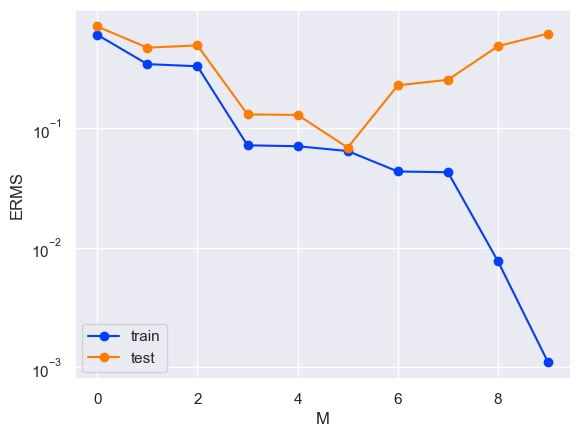

In [9]:
def test_all(start_M, end_M, x_train, y_train, x_test, y_test):
    
    results_train = []
    results_test = []
    all_weights = []
    
    for M in range(start_M, end_M + 1):
        weights = optimial_weights(x_train, y_train, M)
        all_weights.append(weights)
        error_train = erms(weights, x_train, y_train)
        error_test = erms(weights, x_test, y_test)
        results_train.append(error_train)
        results_test.append(error_test)
    return results_train, results_test, all_weights

r_tr, r_tt, all_weights = test_all(0, 9, x_train, y_train, x_test, y_test)

plt.plot(list(range(0, 10)), r_tr, '-o', label='train')
plt.plot(list(range(0, 10)), r_tt, '-o', label='test')
plt.xlabel('M')
plt.ylabel('ERMS')
plt.legend()
plt.yscale('log')

##### Weights table for different `M`

The following code lists the optimal weight vectors obtained for different model order `M` values. Explain what happens to the weights at large values of `M`.

In [10]:
print(pd.DataFrame(all_weights))

          0           1            2             3             4  \
0 -0.067444         NaN          NaN           NaN           NaN   
1  0.674906   -1.403250          NaN           NaN           NaN   
2  0.870601   -2.937208     1.521622           NaN           NaN   
3 -0.348533   11.654727   -33.094539     22.088529           NaN   
4 -0.274931   10.447965   -27.877273     14.161034      3.897826   
5  0.052313    2.957062    24.077616   -126.364847    164.358999   
6  1.343704  -29.263444   282.780618  -1019.109531   1661.058556   
7  1.660030  -39.466949   401.665827  -1667.826277   3460.281781   
8 -2.481221  104.649341 -1466.447102  10136.543433 -36814.842496   
9 -1.502713   61.618488  -721.563398   3546.650638  -4076.784649   

              5             6              7             8             9  
0           NaN           NaN            NaN           NaN           NaN  
1           NaN           NaN            NaN           NaN           NaN  
2           NaN           

##### Estimated curve for `M=9` (same as the amount of data points) 

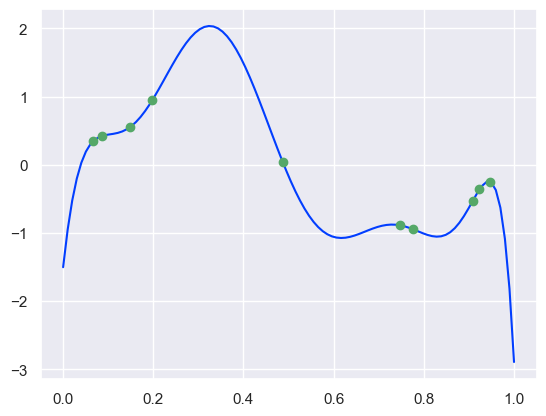

In [11]:
plt.plot(x_test, list(map(lambda x: linear(x, optimial_weights(x_train, y_train, 9)), x_test)), '-')
plt.plot(x_train, y_train, 'og')

## 2) Regularization

### 2.1) Error function

Implement the cost function `err_regularization` that takes into account the regularization term, as given in the equation on slide 16 of Lecture 3. The function should take `weights`, `inputs`, `targets` and `l` (lambda regularization term) as input parameters and compute sum-of-squared error with weight regularization.

In [12]:
def err_regularization(weights, inputs, targets, l):
    w = np.array(weights)
    return (err(weights, inputs, targets)+l/2 *w.T @ w)

err_regularization([1,2,3],[1,2],[2,2], 0.5)


124.0

Write the `erms_regularization` function which is regularization version of a root mean squared error (slide 12 in lecture 3)

In [13]:
def erms_regularization(weights, inputs, targets, l):
    for i in range(len(inputs)):
        total = math.sqrt(2*err_regularization(weights, inputs, targets, l))
        return total


erms_regularization([1,2,3],[1,2],[3,3], -0.5)

14.071247279470288

### 2.2) Optimization

Create a function below that obtains `optimial_weights` by implementing the optimization solution of the regularized problem as given in slide 16 of Lecture 3. The function takes the following parameters: `inputs`, `targets`, `M` (number of weights) and `l` (regularization term) as parameters and returns optimal weights for the given set of training data.

In [14]:
def optimial_weights_regularization(inputs, targets, M, l):
    t = np.array(targets)
    X_T = np.vander(inputs, M+1, increasing= True).T
    X = np.vander(inputs, M+1, increasing= True)    
    total = np.linalg.inv((l * np.identity(M+1)) + X_T @ X) @ X_T @ t
    return total


optimial_weights_regularization([1,3],[1,2],4, 0.5)


array([ 0.27081066,  0.26233519,  0.23690876,  0.1606295 , -0.0682083 ])

### 2.3) Test with regularization

Go through the following code and try to understand its functionality. After that, run the code and interpret the resulting figures.

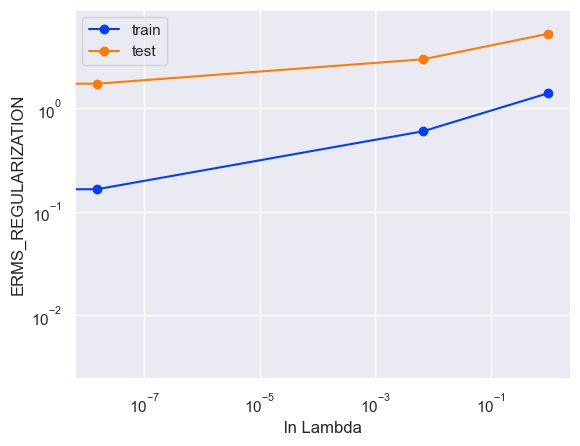

In [15]:
def test_all_regularization(ls, M, x_train, y_train, x_test, y_test):
    
    results_train = []
    results_test = []
    all_weights = []
    
    for l in ls:
        weights = optimial_weights_regularization(x_train, y_train, M, l)
        all_weights.append(weights)
        error_train = erms_regularization(weights, x_train, y_train, l)
        error_test = erms_regularization(weights, x_test, y_test, l)
        results_train.append(error_train)
        results_test.append(error_test)
    return results_train, results_test, all_weights

ls = [0, exp(-18), exp(-5), exp(0)]

r_tr_r, r_tt_r, all_weights_r = test_all_regularization(ls, 9, x_train, y_train, x_test, y_test)

plt.plot(ls, r_tr_r, '-o', label='train')
plt.plot(ls, r_tt_r, '-o', label='test')
plt.xlabel('ln Lambda')
plt.ylabel('ERMS_REGULARIZATION')
plt.legend()
plt.yscale('log')
plt.xscale('log')

##### Weights for `M=9` with regularization terms `0`, `exp(-18)`, `exp(-5)`, `exp(0)`

In [16]:
print(pd.DataFrame(np.transpose(all_weights_r)))

               0           1         2         3
0      -1.502713    0.699011  0.503543  0.328543
1      61.618488  -11.795682  0.743539 -0.389393
2    -721.563398  121.043844 -2.425527 -0.353466
3    3546.650638 -335.150177 -1.908122 -0.232935
4   -4076.784649  217.987060 -0.795824 -0.127092
5  -20923.485954  178.622535  0.106829 -0.046211
6   80617.752637  -87.722827  0.719266  0.013218
7 -116536.802524 -148.839183  1.096707  0.055948
8   78690.997922  -12.387889  1.302133  0.085993
9  -20659.774079   78.207422  1.385740  0.106489


In [17]:
def plot_by_lambda(l):
    plt.plot(x_test, y_test, '-m')
    plt.plot(x_test, list(map(lambda x: linear(x, optimial_weights_regularization(x_train, y_train, 9, l)), x_test)), '-')
    plt.plot(x_train, y_train, 'og')

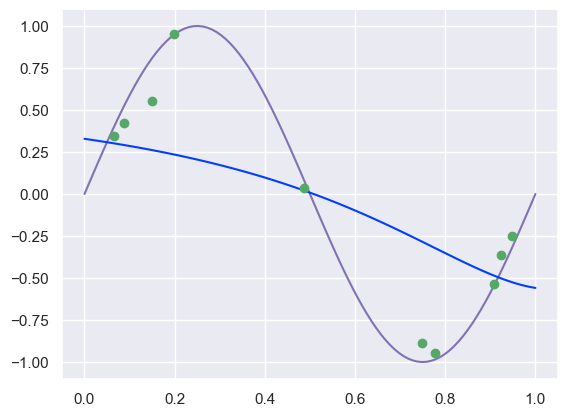

In [18]:
plot_by_lambda(exp(0))

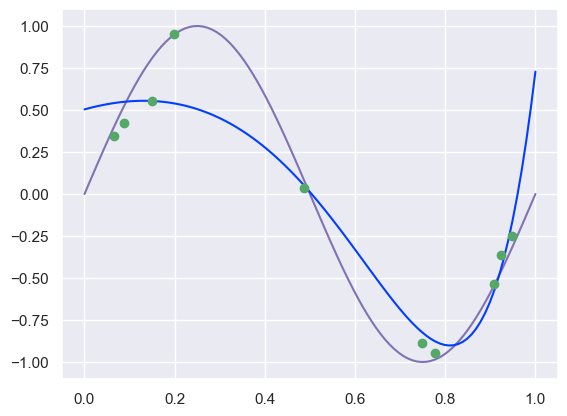

In [19]:
plot_by_lambda(exp(-5))

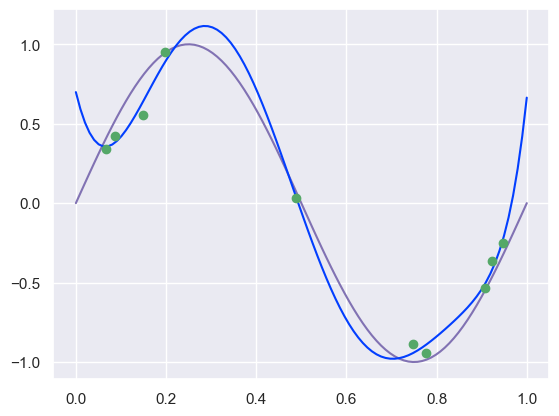

In [20]:
plot_by_lambda(exp(-18))

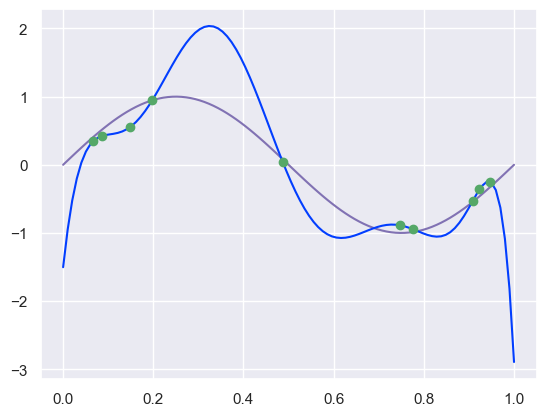

In [21]:
plot_by_lambda(0)

## 3) Model Selection

### 3.1) Cross-validation

Create a function named `create_cross_validation_sets` that takes `S` (number of sets) and training data points `x_train`, `y_train` as parameters and returns array of `S` number sets with each set in the form `[x_sub_train, y_sub_train, x_validation, y_validation]`. Refer to the figure in slide 20 of lecture 3.

In [22]:
def create_cross_validation_sets(S, x_train, y_train):
    result = []
    for i in range(S):
        x_validation = np.array_split(x_train, S)[i]
        y_validation = np.array_split(y_train, S)[i]
        
        x_sub_train = np.concatenate(np.array_split(x_train, S)[:i] + np.array_split(x_train, S)[i+1:])
        y_sub_train = np.concatenate(np.array_split(y_train, S)[:i] + np.array_split(y_train, S)[i+1:])

        
        result.append([x_sub_train, y_sub_train, x_validation, y_validation])
    return result


Create the function, `best_model`, that loops through all integer values between `start_M`, `end_M` (low and high limits in search of optimal value of model order `M`), performs S-fold cross validation (as explained in lecture slides) and selects the best value `top_M` among all the considered values of M.  It also takes `ls` (a list of regularization parameters) and `sets` (cross-validation sets obtained from the output of previous function) and should return `(top_M, top_l, top_result_test)` with `M`, `l` and result for the best model.

M = 5 lambda = 1.522997974471263e-08 erms = 0.10643345643897914


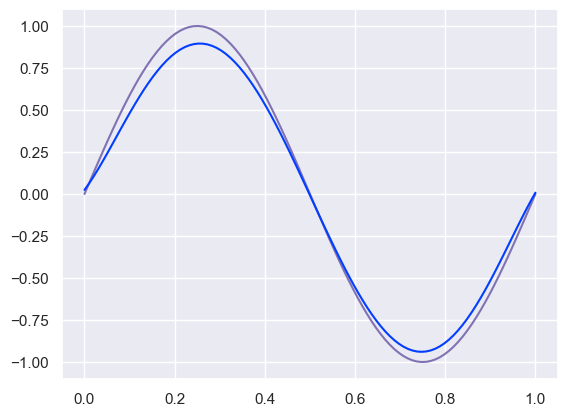

In [23]:
def best_model(start_M, end_M, ls, sets):
    top_M = None
    top_l = None
    top_result_test = 10000000000
    
    for m in range(start_M, end_M + 1):
        for l in ls:
            error = []
            for (x_sub_train, y_sub_train, x_validation, y_validation) in sets:
                
                weights_train = optimial_weights_regularization(x_sub_train, y_sub_train, m, l)
                
                error_rmse = erms(weights_train, x_validation, y_validation)  
                
                error.append(error_rmse)
            
            avg_error = sum(error) / len(error)
            if top_result_test > avg_error:
                top_result_test = avg_error
                top_M = m
                top_l = l
    
    return top_M, top_l, top_result_test



x_cross_train, y_cross_train, _, _ = generate_data(100) 

M, l, r = best_model(0, 9, [0, exp(-18), exp(-5), exp(0)], create_cross_validation_sets(10, x_cross_train, y_cross_train))
print('M =', M, 'lambda =', l, 'erms =', r)

plt.plot(x_test, y_test, '-m')
plt.plot(x_test, list(map(lambda x: linear(x, optimial_weights_regularization(x_train, y_train, M, l)), x_test)), '-')






### Result uses exp(-18) ↑↑